In [1]:
import pandas as pd
import numpy as np
import os
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt
import shap

BASE_PATH = "C:/Users/KEVIN/Downloads/DSRP/Machine Learning I/DSRP_MLE1"
os.chdir(BASE_PATH)

### Carga Data

In [2]:
winesssss = pd.read_parquet("data/processed/winequality-red.parquet", engine='pyarrow')

In [3]:
winesssss.shape

(1599, 12)

In [4]:
winesssss.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Train Test Split

In [5]:
cols = winesssss.drop(columns=['quality']).columns.to_list()
target = 'quality'

In [6]:
X = winesssss[cols]
y = winesssss[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Retirando features correlacionados

In [7]:
cols.remove('fixed acidity')
cols.remove('free sulfur dioxide')

### Train Model

In [8]:
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose = -1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    })
    .sort_values(
        "importance",
        ascending=False
    )
)

print(feature_importance)

MAE: 0.4441746354283745
RMSE: 0.5799661335783954
R2: 0.4852980868150717
                 feature  importance
4              chlorides         755
6   total sulfur dioxide         662
7                density         648
8                     pH         583
1       volatile acidity         570
0          fixed acidity         566
9              sulphates         533
10               alcohol         507
2            citric acid         498
3         residual sugar         405
5    free sulfur dioxide         314


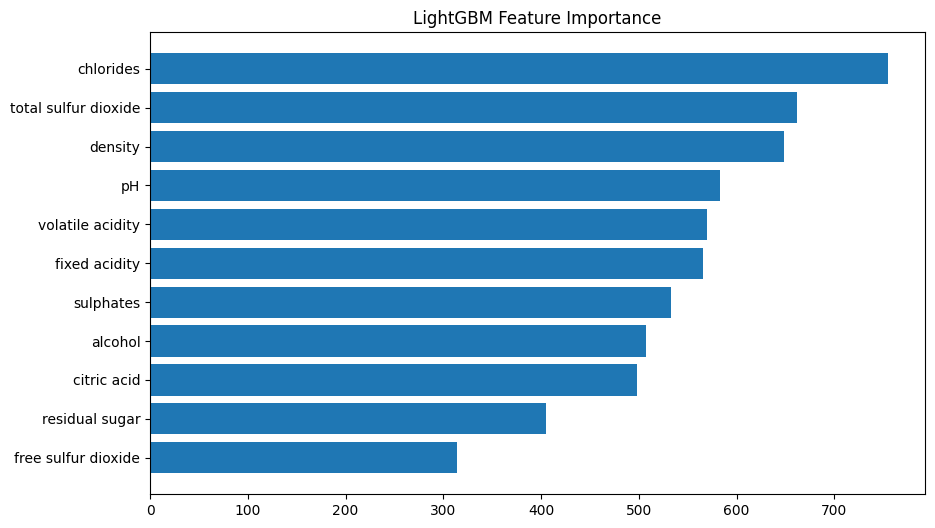

In [10]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.title("LightGBM Feature Importance")
plt.gca().invert_yaxis()
plt.show()

### Interpretacion

In [11]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

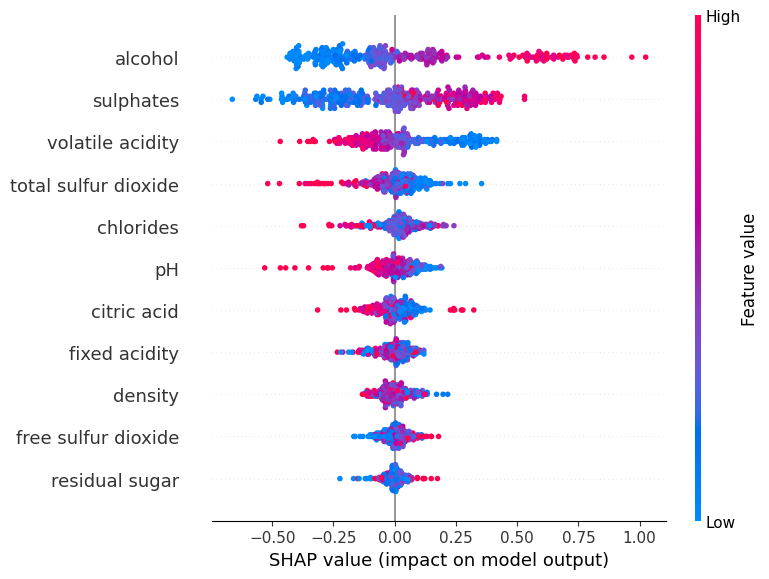

In [12]:
shap.summary_plot(shap_values, X_test)

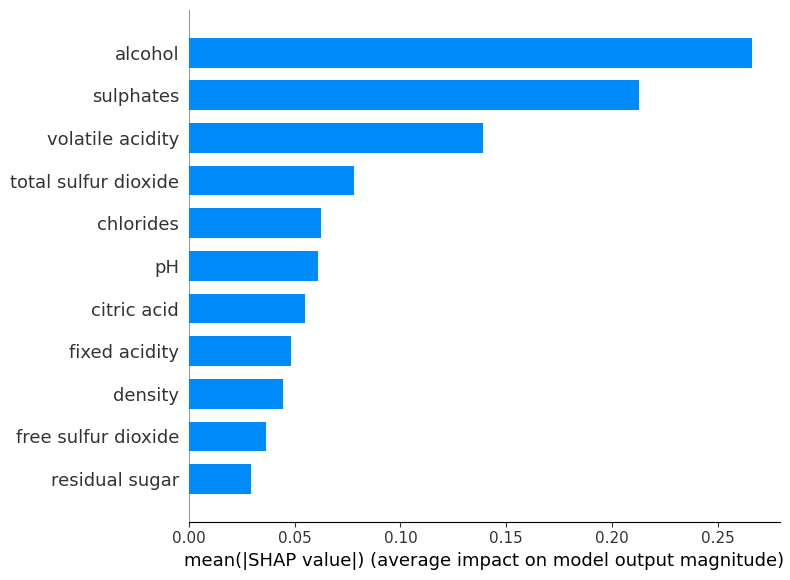

In [13]:
shap.summary_plot(shap_values, X_test, plot_type="bar")